                       PROPORTIONAL LINE-OF-SIGHT (PLOS) GUIDANCE LAW PERFORMANCE DASHBOARD                        

--- [A] PLOS STRAIGHT LINE PERFORMANCE (VARYING PURSUIT GAIN k1) ---
Config       | Mean XTE   | Max XTE    | RMSE       | Final XTE   | Settle Time (5m)  | Settle Time (2m) 
-------------------------------------------------------------------------------------------------------------------
k1 = 5         |   42.332m |   83.997m |   48.236m |    51.708m | DNC               | DNC              
k1 = 10        |   33.329m |   83.997m |   39.982m |     2.205m | 64.38 s           | DNC              
k1 = 40        |   19.123m |   83.997m |   33.226m |     0.000m | 20.86 s           | 21.64 s          
k1 = 60        |   16.830m |   83.997m |   32.611m |     0.000m | 15.18 s           | 16.38 s          
k1 = 80        |   15.825m |   83.997m |   32.819m |     0.000m | 9.80 s            | 12.30 s          
k1 = 100       |   16.773m |   83.997m |   33.264m |     0.000m | 11.62 

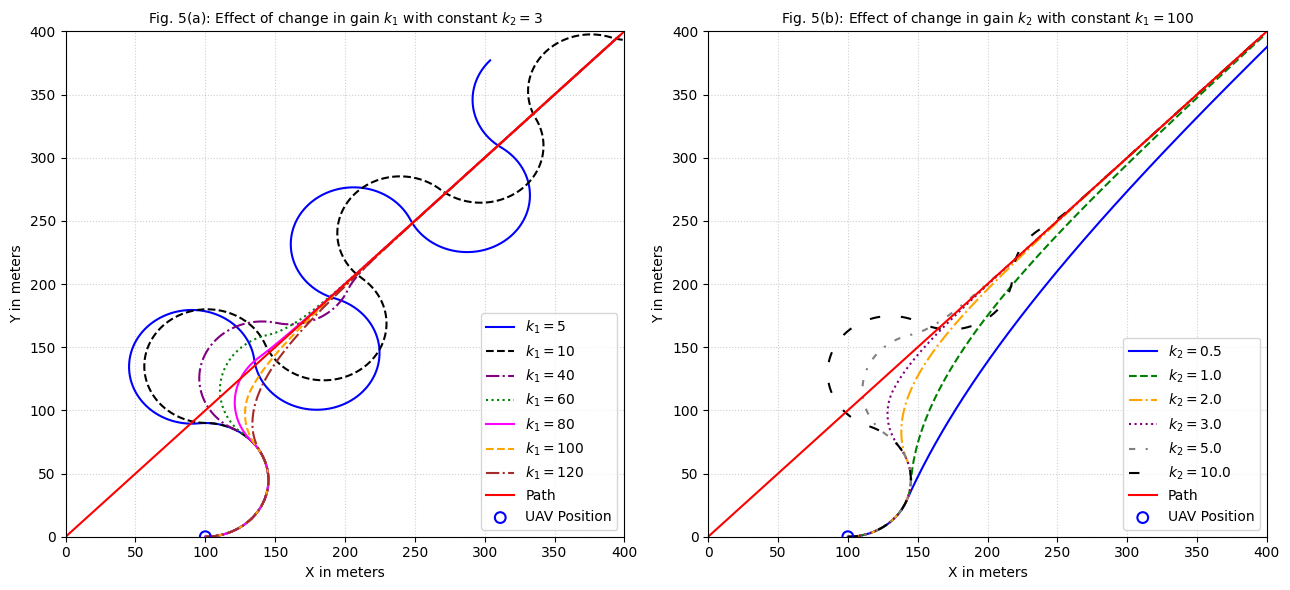

                   PROPORTIONAL LINE-OF-SIGHT (PLOS) LOITER PATH FOLLOWING PERFORMANCE DASHBOARD                   

--- [A] PLOS LOITER PERFORMANCE (VARYING PURSUIT GAIN k1, k2=0.1) ---
Config       | Mean XTE   | Max XTE    | RMSE       | Final XTE   | Settle Time (5m)  | Settle Time (2m) 
-------------------------------------------------------------------------------------------------------------------
k1 = 10        |    4.625m |   72.809m |   13.232m |     1.113m | 26.40 s           | 36.05 s          
k1 = 40        |    9.134m |   72.809m |   19.092m |     0.011m | 77.65 s           | 102.15 s         
k1 = 60        |   13.225m |   72.809m |   22.565m |     0.373m | 115.90 s          | 155.80 s         
k1 = 80        |   17.989m |   72.809m |   25.884m |     2.391m | 169.10 s          | DNC              
k1 = 100       |   21.981m |   72.809m |   28.752m |     4.181m | 227.45 s          | DNC              
k1 = 120       |   25.560m |   72.809m |   31.342m |     6.610m | DNC  

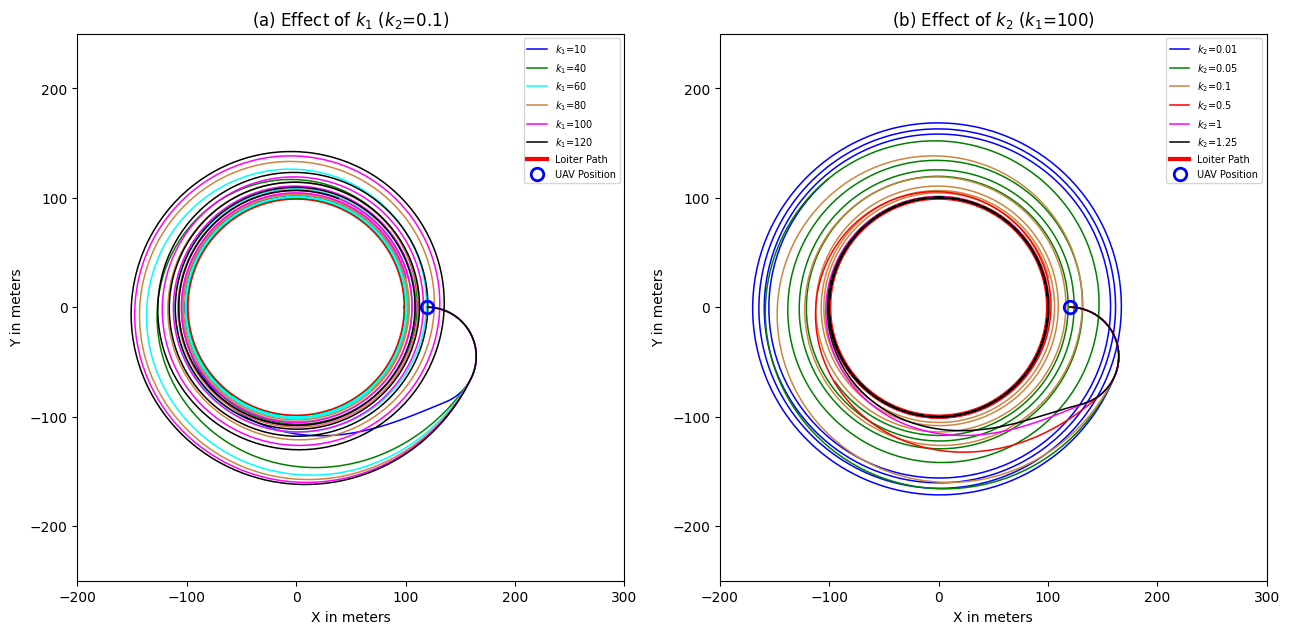

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- UAV Kinematic Constraints & Constants (Section II) ---
va = 15.0          # Airspeed (m/s)
Rmin = 45.0        # Minimum Turning Radius (m)
wmax = va / Rmin   # Max Turning Rate Limit (rad/s)
dt = 0.02          # Fixed time step size (s)
t_max = 65.0       # Max execution simulation window (s)
steps = int(t_max / dt)

def simulate_plos_exact(k1, k2):
    # Defining path segment from W_i=(0,0) to W_i+1=(400,400)
    W_i = np.array([0.0, 0.0])
    W_next = np.array([400.0, 400.0])

    # Path line-of-sight angle (theta = 45 degrees = pi/4)
    theta = np.arctan2(W_next[1] - W_i[1], W_next[0] - W_i[0])

    # Initial state setup from Figure 5: Location=(100,0), Heading=0.0 rad
    x, y = 100.0, 0.0
    psi = 0.0

    x_hist, y_hist = [x], [y]

    for _ in range(steps):
        # Calculate components relative to the line origin
        Ru = np.hypot(x - W_i[0], y - W_i[1])
        theta_u = np.arctan2(y - W_i[1], x - W_i[0])

        # Exact cross-track error distance (d)
        d = Ru * np.sin(theta - theta_u)

        # Pure pursuit line orientation tracking
        error_pursuit = np.arctan2(np.sin(theta - psi), np.cos(theta - psi))

        # Combined PLOS guidance law yielding the steering rate command
        u = k1 * error_pursuit + k2 * d

        # Saturation checks for physical turn limits
        u = np.clip(u, -wmax, wmax)

        # System kinematics integration
        x += va * np.cos(psi) * dt
        y += va * np.sin(psi) * dt
        psi += u * dt

        x_hist.append(x)
        y_hist.append(y)

        # Terminate cleanly only when close to final waypoint marker
        if np.hypot(W_next[0] - x, W_next[1] - y) < 5.0:
            break

    return np.array(x_hist), np.array(y_hist)

# =============================================================================
# ERROR ANALYSIS METRICS HELPER FUNCTIONS
# =============================================================================
def calculate_settling_time(xte_array, threshold, time_step=dt):
    """Finds the time when XTE drops below a threshold and remains there permanently."""
    above_threshold_indices = np.where(xte_array >= threshold)[0]
    if len(above_threshold_indices) == 0:
        return 0.0  # Already settled below the threshold at step 0

    last_above_index = above_threshold_indices[-1]
    # If the last index above threshold is the final element, it never permanently settled
    if last_above_index == len(xte_array) - 1:
        return None

    return (last_above_index + 1) * time_step

def compute_plos_errors(xs, ys):
    """Calculates spatial tracking errors relative to a perfect 45-degree line diagonal (y = x)"""
    xte = np.abs(xs - ys) / np.sqrt(2)
    mean_xte = np.mean(xte)
    max_xte = np.max(xte)
    rmse = np.sqrt(np.mean(xte**2))
    final_xte = xte[-1]
    ts_5m = calculate_settling_time(xte, threshold=5.0)
    ts_2m = calculate_settling_time(xte, threshold=2.0)
    return mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m

# --- Plot Architecture Layout Design ---
plt.figure(figsize=(13, 6))

print("=" * 115)
print(f"{'PROPORTIONAL LINE-OF-SIGHT (PLOS) GUIDANCE LAW PERFORMANCE DASHBOARD':^115}")
print("=" * 115)

# =============================================================================
# FIGURE 5(a): Varying Gain k1 (Constant k2 = 3)
# =============================================================================
plt.subplot(1, 2, 1)
k1_vals = [5, 10, 40, 60, 80, 100, 120]
colors_a = ['blue', 'black', 'purple', 'green', 'magenta', 'orange', 'brown']
styles_a = ['-', '--', '-.', ':', '-', '--', '-.']

print("\n--- [A] PLOS STRAIGHT LINE PERFORMANCE (VARYING PURSUIT GAIN k1) ---")
header = f"{'Config':<12} | {'Mean XTE':<10} | {'Max XTE':<10} | {'RMSE':<10} | {'Final XTE':<11} | {'Settle Time (5m)':<17} | {'Settle Time (2m)':<17}"
print(header)
print("-" * 115)

for k1, col, sty in zip(k1_vals, colors_a, styles_a):
    x_t, y_t = simulate_plos_exact(k1=k1, k2=3.0)

    # Calculate performance metrics on the generated dataset
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_plos_errors(x_t, y_t)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"
    print(f"k1 = {k1:<9} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

    plt.plot(x_t, y_t, label=f'$k_1 = {k1}$', color=col, linestyle=sty, linewidth=1.5)

plt.plot([0, 400], [0, 400], 'r-', linewidth=1.5, label='Path')
plt.scatter([100], [0], facecolors='none', edgecolors='blue', s=60, linewidths=1.5, label='UAV Position', zorder=5)
plt.title('Fig. 5(a): Effect of change in gain $k_1$ with constant $k_2 = 3$', fontsize=10)
plt.xlabel('X in meters')
plt.ylabel('Y in meters')
plt.xlim(0, 400)
plt.ylim(0, 400)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

# =============================================================================
# FIGURE 5(b): Varying Gain k2 (Constant k1 = 100)
# =============================================================================
plt.subplot(1, 2, 2)
k2_vals = [0.5, 1.0, 2.0, 3.0, 5.0, 10.0]
colors_b = ['blue', 'green', 'orange', 'purple', 'gray', 'black']
styles_b = ['-', '--', '-.', ':', (0, (3, 5, 1, 5)), (0, (5, 10))]

print("\n--- [B] PLOS STRAIGHT LINE PERFORMANCE (VARYING CROSS-TRACK GAIN k2) ---")
print(header)
print("-" * 115)

for k2, col, sty in zip(k2_vals, colors_b, styles_b):
    x_t, y_t = simulate_plos_exact(k1=100.0, k2=k2)

    # Calculate performance metrics on the generated dataset
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_plos_errors(x_t, y_t)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"
    print(f"k2 = {k2:<9} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

    plt.plot(x_t, y_t, label=f'$k_2 = {k2}$', color=col, linestyle=sty, linewidth=1.5)

plt.plot([0, 400], [0, 400], 'r-', linewidth=1.5, label='Path')
plt.scatter([100], [0], facecolors='none', edgecolors='blue', s=60, linewidths=1.5, label='UAV Position', zorder=5)
plt.title('Fig. 5(b): Effect of change in gain $k_2$ with constant $k_1 = 100$', fontsize=10)
plt.xlabel('X in meters')
plt.ylabel('Y in meters')
plt.xlim(0, 400)
plt.ylim(0, 400)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

print("\n" + "=" * 115)

plt.tight_layout()
plt.show()

# Commented out IPython magic to ensure Python compatibility.
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

# ---------------- UAV / loiter parameters (pixel-calibrated from the PDF) ----------------
va = 15.0                    # airspeed, m/s
R_min = 45.0                 # min turning radius, m
omega_max = va / R_min       # max turn rate, rad/s

O = np.array([0.0, 0.0])     # loiter center
r = 100.0                    # loiter radius, m

p0 = np.array([120.0, 0.0])  # UAV start position (pixel-extracted marker location)
psi0 = 0.0                    # initial heading — facing AWAY from the loiter center
LOITER_DIR = -1               # loiter direction: -1 = CW, +1 = CCW

dt = 0.05
T = 250.0   # long enough for every k1/k2 value to fully converge onto the circle

def wrap(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))

def simulate_plos_loiter(k1, k2, dir_=LOITER_DIR):
    """
    PLOS combined guidance law, adapted to loiter geometry:
      d       = ||O - p|| - r                      (cross-track error)
      theta   = atan2(y-yl, x-xl)                   (radial bearing to loiter center)
      theta_p = theta + dir*(pi/2)                  (tangential reference heading)
      u       = k1*(theta_p - psi) + k2*d*dir        (turn-rate command)
      u       = clip(u, -omega_max, omega_max)
    """
    x, y, psi = p0[0], p0[1], psi0
    xs, ys = [x], [y]
    for _ in range(int(T / dt)):
        theta = np.arctan2(y - O[1], x - O[0])
        theta_p = theta + dir_ * (np.pi / 2)
        d = np.hypot(x - O[0], y - O[1]) - r

        u = k1 * wrap(theta_p - psi) + k2 * d * dir_
        u = np.clip(u, -omega_max, omega_max)

        psi += u * dt
        x += va * np.cos(psi) * dt
        y += va * np.sin(psi) * dt
        xs.append(x); ys.append(y)
    return np.array(xs), np.array(ys)

# =============================================================================
# ERROR ANALYSIS METRICS HELPER FUNCTIONS
# =============================================================================
def calculate_settling_time(xte_array, threshold, time_step=dt):
    """Finds the time when XTE drops below a threshold and remains there permanently."""
    above_threshold_indices = np.where(xte_array >= threshold)[0]
    if len(above_threshold_indices) == 0:
        return 0.0  # Already settled below the threshold at step 0

    last_above_index = above_threshold_indices[-1]
    # If the last index above threshold is the final element, it never permanently settled
    if last_above_index == len(xte_array) - 1:
        return None

    return (last_above_index + 1) * time_step

def compute_loiter_errors(xs, ys, center=O, radius=r):
    """Calculates spatial tracking errors relative to the circular orbit track"""
    radial_distances = np.hypot(xs - center[0], ys - center[1])
    xte = np.abs(radial_distances - radius)
    mean_xte = np.mean(xte)
    max_xte = np.max(xte)
    rmse = np.sqrt(np.mean(xte**2))
    final_xte = xte[-1]
    ts_5m = calculate_settling_time(xte, threshold=5.0)
    ts_2m = calculate_settling_time(xte, threshold=2.0)
    return mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m

# --- Layout Initialization ---
fig, axs = plt.subplots(1, 2, figsize=(13, 6.5))
th = np.linspace(0, 2*np.pi, 200)

print("=" * 115)
print(f"{'PROPORTIONAL LINE-OF-SIGHT (PLOS) LOITER PATH FOLLOWING PERFORMANCE DASHBOARD':^115}")
print("=" * 115)

# ---------------- Panel (a): vary k1, k2=0.1 fixed ----------------
k1_values = [10, 40, 60, 80, 100, 120]
colors_a = ['blue', 'green', 'cyan', 'peru', 'magenta', 'black']

print("\n--- [A] PLOS LOITER PERFORMANCE (VARYING PURSUIT GAIN k1, k2=0.1) ---")
header = f"{'Config':<12} | {'Mean XTE':<10} | {'Max XTE':<10} | {'RMSE':<10} | {'Final XTE':<11} | {'Settle Time (5m)':<17} | {'Settle Time (2m)':<17}"
print(header)
print("-" * 115)

for k1, c in zip(k1_values, colors_a):
    xs, ys = simulate_plos_loiter(k1, k2=0.1)

    # Calculate performance metrics on the generated dataset
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_loiter_errors(xs, ys)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"
    print(f"k1 = {k1:<9} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

    axs[0].plot(xs, ys, color=c, linewidth=1.1, label=f'$k_1$={k1}')

axs[0].plot(O[0]+r*np.cos(th), O[1]+r*np.sin(th), 'r-', linewidth=3, label='Loiter Path', zorder=0)
axs[0].plot(p0[0], p0[1], 'o', mfc='none', mec='blue', mew=2, ms=9, label='UAV Position')
axs[0].set_xlim(-200, 300); axs[0].set_ylim(-250, 250); axs[0].set_aspect('equal')
axs[0].set_xlabel('X in meters'); axs[0].set_ylabel('Y in meters')
axs[0].legend(fontsize=7); axs[0].set_title('(a) Effect of $k_1$ ($k_2$=0.1)')

# ---------------- Panel (b): vary k2, k1=100 fixed ----------------
k2_values = [0.01, 0.05, 0.1, 0.5, 1, 1.25]
colors_b = ['blue', 'green', 'peru', 'red', 'magenta', 'black']

print("\n--- [B] PLOS LOITER PERFORMANCE (VARYING CROSS-TRACK GAIN k2, k1=100) ---")
print(header)
print("-" * 115)

for k2, c in zip(k2_values, colors_b):
    xs, ys = simulate_plos_loiter(k1=100, k2=k2)

    # Calculate performance metrics on the generated dataset
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_loiter_errors(xs, ys)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"
    print(f"k2 = {k2:<9} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

    axs[1].plot(xs, ys, color=c, linewidth=1.1, label=f'$k_2$={k2}')

axs[1].plot(O[0]+r*np.cos(th), O[1]+r*np.sin(th), 'r-', linewidth=3, label='Loiter Path', zorder=0)
axs[1].plot(p0[0], p0[1], 'o', mfc='none', mec='blue', mew=2, ms=9, label='UAV Position')
axs[1].set_xlim(-200, 300); axs[1].set_ylim(-250, 250); axs[1].set_aspect('equal')
axs[1].set_xlabel('X in meters'); axs[1].set_ylabel('Y in meters')
axs[1].legend(fontsize=7); axs[1].set_title('(b) Effect of $k_2$ ($k_1$=100)')

print("\n" + "=" * 115)

plt.tight_layout()
plt.show()